# Raag Recogntion Software


In [1]:
# Imports
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import wavfile
from scipy.signal import stft
import os
from pathlib import Path
import librosa

In [8]:

dir_path = str(Path.cwd())
file_path_gorag_khalyan = os.path.join(dir_path, "Data", "Sound", "Gorag_Khalyan", "Raag_Gorag_Khalyan.mp3")
file_path_Jog = os.path.join(dir_path, "Data", "Sound", "Jog", "Raag_Jog.mp3")
Sr = 22050  # Common sampling rate for audio processing
# print(f"Reading audio from: {file_path}")
# audio, sr = librosa.load(file_path, sr=None)
# print("Duration (seconds):", len(audio) / sr)
# Normalize (helps visualization)


In [3]:
import librosa
import numpy as np


def sliding_spectrograms(audio, sr, window_sec=10, hop_sec=5,
                         n_fft=1024, hop_length=512):
    
    window_samples = int(window_sec * sr)
    hop_samples = int(hop_sec * sr)

    spectrograms = []

    for start in range(0, len(audio) - window_samples + 1, hop_samples):
        segment = audio[start:start + window_samples]

        # STFT
        S = np.abs(librosa.stft(segment,
                                n_fft=n_fft,
                                hop_length=hop_length))

        # Convert to dB
        S_db = librosa.amplitude_to_db(S, ref=np.max)

        spectrograms.append(S_db)

    return spectrograms

In [4]:

def raag_mel_spectrogram(file_path, start_sec=0, duration=10):
    
    audio, sr = librosa.load(
        file_path,
        sr=22050,
        offset=start_sec,
        duration=duration
    )

    S = librosa.feature.melspectrogram(
        y=audio,
        sr=sr,
        n_fft=4096,
        hop_length=512,
        n_mels=128,
        fmin=50,
        fmax=2000
    )

    S_db = librosa.power_to_db(S, ref=np.max)
    return S_db, sr


def plot_spectrogram(S_db, sr):
    plt.figure(figsize=(10, 4))
    librosa.display.specshow(
        S_db,
        sr=sr,
        x_axis='time',
        y_axis='mel'
    )
    plt.colorbar(label="dB")
    plt.title("Raag Mel Spectrogram")
    plt.tight_layout()
    plt.show()

In [5]:
def generate_raag_dataset(file_path,
                          window_sec=10,
                          hop_sec=5):

    audio, sr = librosa.load(file_path, sr=22050)

    window_samples = int(window_sec * sr)
    hop_samples = int(hop_sec * sr)

    dataset = []

    for start in range(0, len(audio) - window_samples + 1, hop_samples):
        segment = audio[start:start + window_samples]

        S = librosa.feature.melspectrogram(
            y=segment,
            sr=sr,
            n_fft=4096,
            hop_length=512,
            n_mels=128,
            fmin=50,
            fmax=2000
        )

        dataset.append(librosa.power_to_db(S, ref=np.max))

    return np.array(dataset)

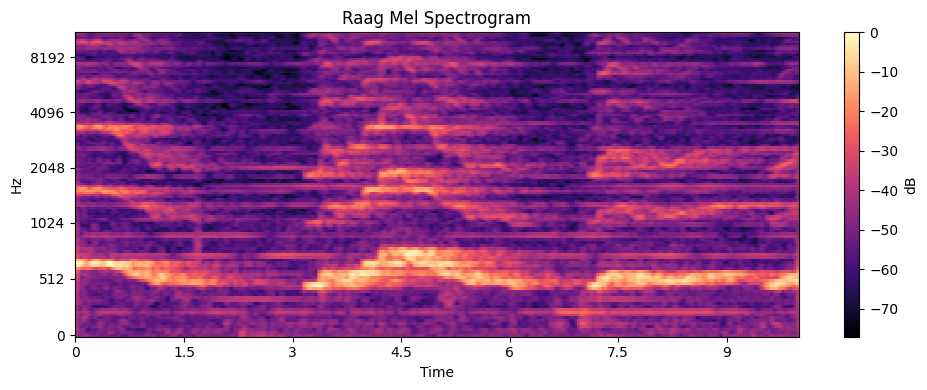

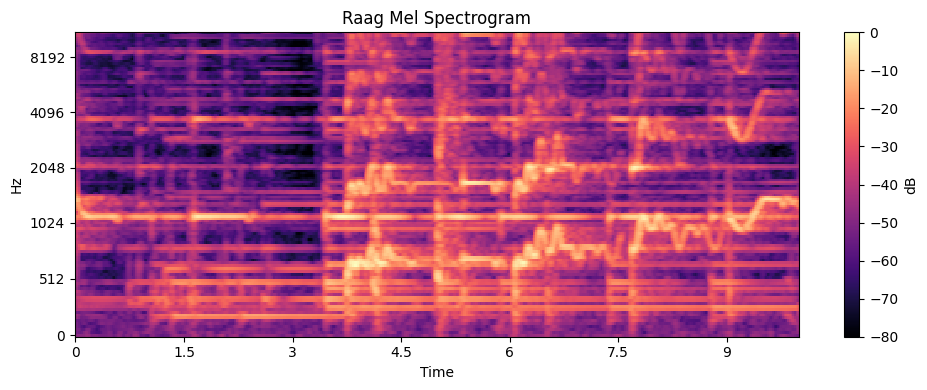

In [46]:
S_dB_1, Sr = raag_mel_spectrogram(file_path_gorag_khalyan, start_sec=500, duration=10)
S_dB_2, Sr = raag_mel_spectrogram(file_path_Jog, start_sec=800, duration=10)
# data = generate_raag_dataset(file_path, window_sec=10, hop_sec=5)
plot_spectrogram(S_dB_1, Sr)
plot_spectrogram(S_dB_2, Sr)


In [10]:
import matplotlib.pyplot as plt
import os


def save_spectrograms(output_dir_GK, data, Sr):
    for i, S_db in enumerate(data):
        plt.figure(figsize=(10, 5))
        librosa.display.specshow(S_db, sr=Sr, x_axis='time', y_axis='hz')
        plt.colorbar()
        plt.title(f"Segment {i}")
        plt.tight_layout()
        plt.savefig(f"{output_dir_GK}/spec_{i:04d}.png")
        plt.close()

In [11]:
output_dir_GK = os.path.join(dir_path, "Data", "Spectrograms","Gorag_Khalyan")
os.makedirs(output_dir_GK, exist_ok=True)

data = generate_raag_dataset(file_path_gorag_khalyan, window_sec=10, hop_sec=5)
data = data[20:240]

save_spectrograms(output_dir_GK, data, Sr)

In [12]:
output_dir_Jog = os.path.join(dir_path, "Data", "Spectrograms","Jog")
os.makedirs(output_dir_Jog, exist_ok=True)

data = generate_raag_dataset(file_path_Jog, window_sec=10, hop_sec=5)
data = data[20:220]

save_spectrograms(output_dir_Jog, data, Sr)